<a href="https://colab.research.google.com/github/Sumit05-Y/EDA-DATASCIENCE/blob/main/NABIL(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

nabil = pd.read_csv("NABIL_clean.csv")
nabil["Date"] = pd.to_datetime(nabil["Date"])
nabil.head()
nabil.info()
nabil.tail()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            223 non-null    datetime64[ns]
 1   Open            223 non-null    float64       
 2   High            223 non-null    float64       
 3   Low             223 non-null    float64       
 4   Close           223 non-null    float64       
 5   Percent Change  223 non-null    float64       
 6   Volume          223 non-null    float64       
 7   Daily Return    222 non-null    float64       
 8   MA20            204 non-null    float64       
 9   MA50            174 non-null    float64       
 10  Volatility      203 non-null    float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 19.3 KB


,Date,Open,High,Low,Close,Percent Change,Volume,Daily Return,MA20,MA50,Volatility
218,2026-06-30,526.0,527.0,520.20,521.9,-0.40,24993.0,-0.400763,530.710,528.466,0.385513
219,2026-07-01,520.0,526.0,515.09,525.0,0.59,44906.0,0.593984,530.135,528.366,0.419087
220,2026-07-02,530.0,545.2,512.00,541.0,3.05,231443.0,3.047619,530.245,528.626,0.816317
221,2026-07-03,540.0,541.0,519.00,530.0,-2.03,114343.0,-2.033272,529.995,528.706,0.925434
222,2026-07-06,530.0,535.0,523.00,526.0,-0.75,37851.0,-0.754717,529.645,528.696,0.936456


In [14]:

nabil["Next_Close"] = nabil["Close"].shift(-1)
nabil["Direction"] = (nabil["Next_Close"] > nabil["Close"]).astype(int)


In [15]:
features = ["Open", "High", "Low", "Volume", "MA20", "MA50"]

data = nabil.dropna(subset=features + ["Direction"]).reset_index(drop=True)

X = data[features]
y = data["Direction"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [19]:
import time
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM (RBF)": SVC(random_state=42),
    "KNN": KNeighborsClassifier(),
}
results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start
    pred = model.predict(X_test_scaled)
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "Train time (ms)": train_time * 1000,
    })

results_df = pd.DataFrame(results)
print(results_df.round(3))



           Model  Accuracy  Precision  Recall     F1  Train time (ms)
0  Decision Tree     0.457      0.357   0.333  0.345           14.574
1  Random Forest     0.543      0.455   0.333  0.385         1162.878
2      SVM (RBF)     0.486      0.000   0.000  0.000           24.598
3            KNN     0.457      0.357   0.333  0.345            5.329


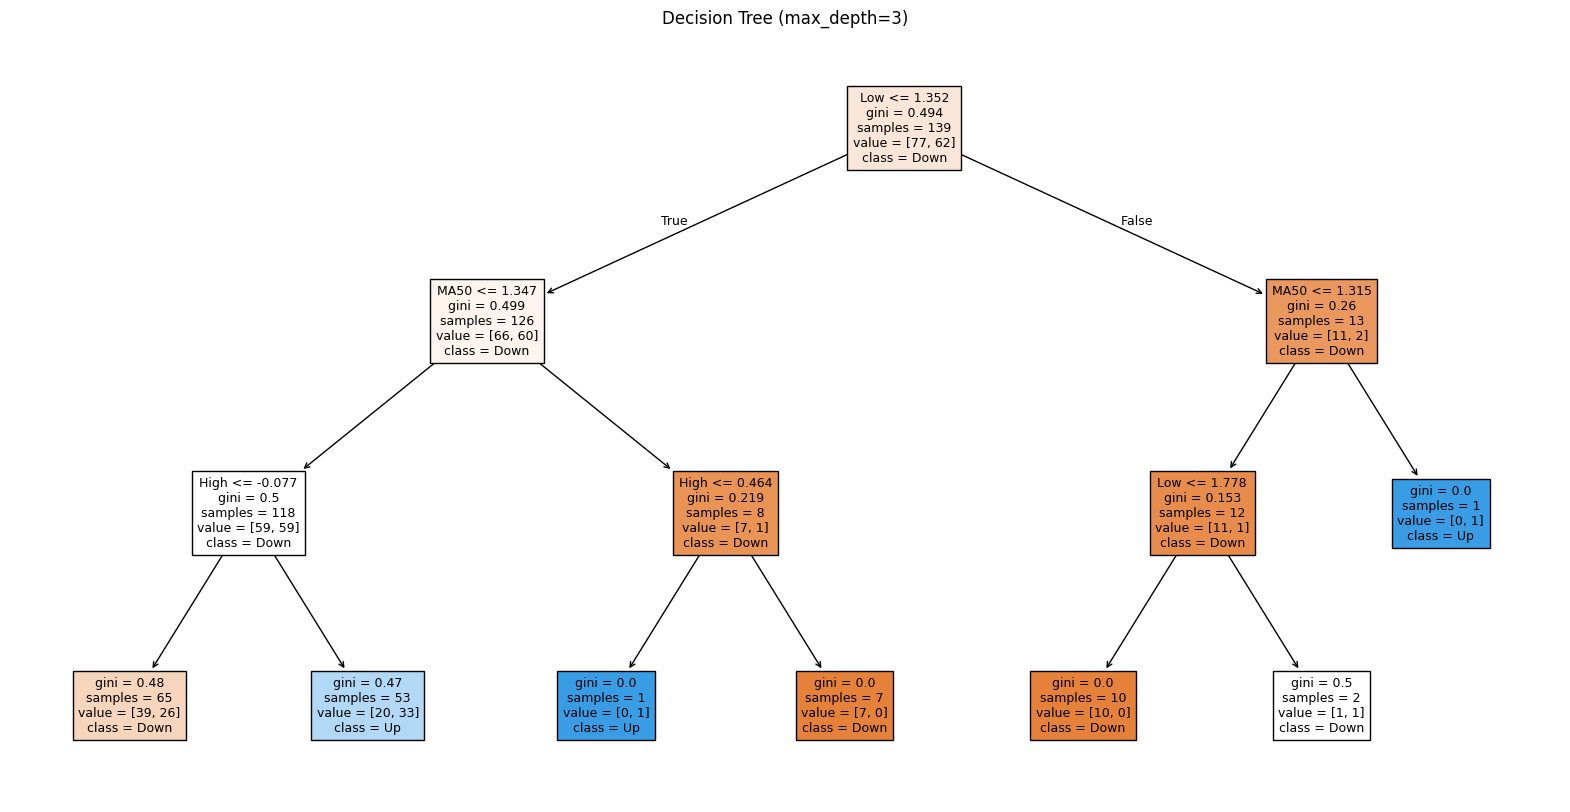

In [21]:
plt.figure(figsize=(20, 10))

small_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
small_tree.fit(X_train_scaled, y_train)

plot_tree(
    small_tree,
    feature_names=features,
    class_names=["Down", "Up"],
    filled=True,
    fontsize=9
)

plt.title("Decision Tree (max_depth=3)")
plt.show()

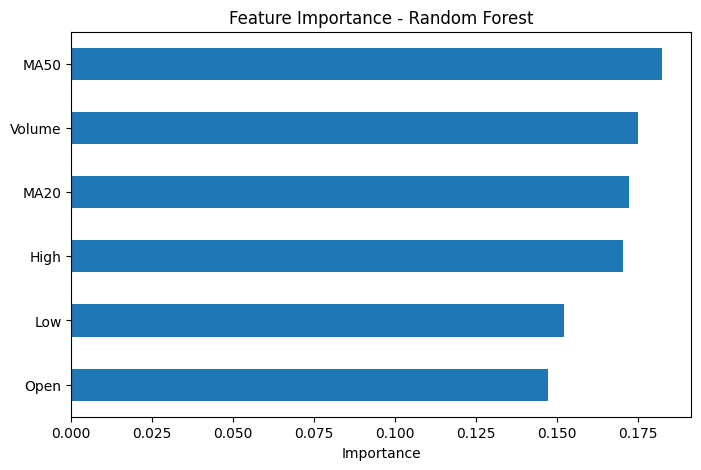

In [26]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

importances = pd.Series(rf.feature_importances_, index=features)

importances.sort_values(ascending=False).plot(kind="barh", figsize=(8,5))
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()